In [ ]:
import os
# 1. 优先设置所有的环境变量（必须在 import torch 之前！）
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # 解决 Mac M4 内核崩溃问题
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'    # 限制服务器上只用 0,1 号卡

import sys
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# 2. 智能识别设备（此时服务器上的 cuda:0 实际对应的就是物理上的 0 号卡）
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"代码自动识别并连接到了: {device}")


代码自动识别并连接到了: mps


In [11]:
from torchvision import datasets
from torchvision.transforms import ToTensor
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("training data size", len(training_data))
print("test data size", len(test_data))

training data size 60000
test data size 10000


In [3]:
image, label = training_data[0]
print(image.shape)
print(image.dtype)
print(image.min())
print(image.max())
print(label)

torch.Size([1, 28, 28])
torch.float32
tensor(0.)
tensor(1.)
5


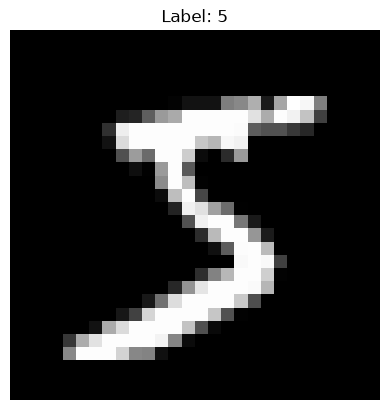

In [4]:
# show image
import matplotlib.pyplot as plt
plt.imshow(image.squeeze(0), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


In [5]:
train_loader = DataLoader(
    training_data,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)
print("Training samples:", len(training_data))
print("Test samples:", len(test_data))
print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training samples: 60000
Test samples: 10000
Training batches: 938
Test batches: 157


In [6]:
images, labels = next(iter(train_loader))
print("Images shape:", images.shape) # batch=64, channel=1, height=28, width=28
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)
print("Pixel range:", images.min().item(), images.max().item())


Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
Images dtype: torch.float32
Labels dtype: torch.int64
Pixel range: 0.0 1.0


In [ ]:
model = nn.Sequential(
    nn.Flatten(), # shape: (64, 1, 28, 28) => (64, 784)
    nn.Linear(28 * 28, 128), # shape: (64, 784) => (64, 128)
    nn.ReLU(),
    nn.Linear(128, 10) # shape: (64, 128) => (64, 10)
)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for trained_image, trained_label in train_loader:
        optimizer.zero_grad()
        logit = model(trained_image)
        loss = loss_fn(logit, trained_label)
        loss.backward()
        optimizer.step()
        # sum each batch's loss
        batch_size = trained_label.size(0)
        total_loss += loss.item() * batch_size # multiply batch_size because loss.item() is the average of the batch.
        predictions = logit.argmax(dim=1)
        total_correct += (predictions == trained_label).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples


    print(
        f"Epoch {epoch + 1}, "
        f"loss={epoch_loss:.4f}, "
        f"accuracy={epoch_accuracy:.2%}"
    )

model.eval()
test_loss_total = 0.0
test_correct = 0
test_samples = 0
with torch.no_grad():
    for test_image, test_label in test_loader:
        test_logits = model(test_image)
        loss = loss_fn(test_logits, test_label)
        test_prediction = test_logits.argmax(dim=1)
        # sum each batch's loss
        batch_size = test_label.size(0)
        test_loss_total += loss.item() * batch_size
        test_correct += (test_prediction == test_label).sum().item()
        test_samples += batch_size

    test_loss = test_loss_total / test_samples
    test_accuracy = test_correct / test_samples

    print(f"\nTest loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_accuracy:.2%}")



Epoch 1, loss=0.3452, accuracy=90.74%
Epoch 2, loss=0.1559, accuracy=95.56%
Epoch 3, loss=0.1085, accuracy=96.89%
Epoch 4, loss=0.0824, accuracy=97.62%
Epoch 5, loss=0.0652, accuracy=98.14%
Epoch 6, loss=0.0528, accuracy=98.45%
Epoch 7, loss=0.0432, accuracy=98.78%
Epoch 8, loss=0.0345, accuracy=99.00%
Epoch 9, loss=0.0289, accuracy=99.17%
Epoch 10, loss=0.0244, accuracy=99.31%

Test loss: 0.0708
Test accuracy: 97.81%


In [28]:
# import necessary package
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# setup hyperparameters
batch_size = 64
learning_rate = 0.001
num_epochs = 20

# prepare MNIST dataset
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# organize to DataLoader
train_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)



# define class:
class MNISTMLP(nn.Module):
    # initation --- layers setup
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.output = nn.Linear(128, 10)

    # put layers together
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        logits = self.output(x)
        return logits

# create model --- setup loss function and optimizer
model = MNISTMLP()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# define training epoch function
def train_one_epoch(model, data_loader, loss_fn, optimizer):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        # sum each batch's loss
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size # multiply batch_size because loss.item() is the average of the batch.
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples


    return epoch_loss, epoch_accuracy

# define evaluation function
def evaluate(model, data_loader, loss_fn):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            logits = model(images)
            loss = loss_fn(logits, labels)
            predictions = logits.argmax(dim=1)
            # sum each batch's loss
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

        test_loss = total_loss / total_samples
        test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy

# history record
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

for epoch in range(num_epochs):
    # 训练一个完整 epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer
    )

    # 使用当前模型评价测试集
    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        loss_fn
    )

    # 保存历史数据
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    # 显示当前训练结果
    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"train loss={train_loss:.4f}, "
        f"train accuracy={train_accuracy:.2%}, "
        f"test loss={test_loss:.4f}, "
        f"test accuracy={test_accuracy:.2%}"
    )

Epoch 1/20, train loss=0.3419, train accuracy=90.79%, test loss=0.1950, test accuracy=94.20%
Epoch 2/20, train loss=0.1564, train accuracy=95.49%, test loss=0.1201, test accuracy=96.50%
Epoch 3/20, train loss=0.1088, train accuracy=96.91%, test loss=0.0974, test accuracy=97.03%
Epoch 4/20, train loss=0.0815, train accuracy=97.56%, test loss=0.0871, test accuracy=97.29%
Epoch 5/20, train loss=0.0636, train accuracy=98.12%, test loss=0.0799, test accuracy=97.44%
Epoch 6/20, train loss=0.0513, train accuracy=98.50%, test loss=0.0781, test accuracy=97.47%
Epoch 7/20, train loss=0.0413, train accuracy=98.78%, test loss=0.0735, test accuracy=97.81%
Epoch 8/20, train loss=0.0332, train accuracy=99.03%, test loss=0.0734, test accuracy=97.70%
Epoch 9/20, train loss=0.0284, train accuracy=99.18%, test loss=0.0734, test accuracy=97.64%
Epoch 10/20, train loss=0.0229, train accuracy=99.40%, test loss=0.0808, test accuracy=97.61%
Epoch 11/20, train loss=0.0191, train accuracy=99.49%, test loss=0.07

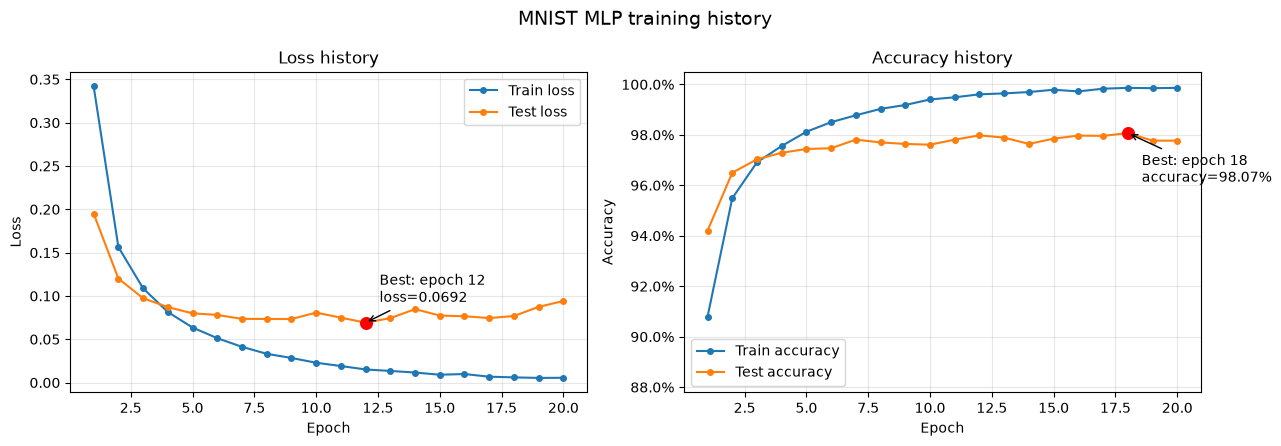

In [29]:
# drawing
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Epoch 横坐标：1, 2, ..., num_epochs
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)

# ------------------------------------------------------------
# 左图：Loss
# ------------------------------------------------------------

axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    markersize=4,
    label="Train loss"
)

axes[0].plot(
    epochs,
    history["test_loss"],
    marker="o",
    markersize=4,
    label="Test loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss history")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 找出测试损失最低的 epoch
best_loss_index = history["test_loss"].index(
    min(history["test_loss"])
)

best_loss_epoch = best_loss_index + 1
best_test_loss = history["test_loss"][best_loss_index]

# 标记测试损失最低点
axes[0].scatter(
    best_loss_epoch,
    best_test_loss,
    color="red",
    s=70,
    zorder=3,
    label="Best test loss"
)

axes[0].annotate(
    f"Best: epoch {best_loss_epoch}\nloss={best_test_loss:.4f}",
    xy=(best_loss_epoch, best_test_loss),
    xytext=(10, 15),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)


# ------------------------------------------------------------
# 右图：Accuracy
# ------------------------------------------------------------

axes[1].plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    markersize=4,
    label="Train accuracy"
)

axes[1].plot(
    epochs,
    history["test_accuracy"],
    marker="o",
    markersize=4,
    label="Test accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy history")
axes[1].grid(alpha=0.3)
axes[1].legend()

# 把 0.98 显示为 98%
axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)

# 根据实际准确率动态调整纵轴，方便看清差异
all_accuracies = (
    history["train_accuracy"]
    + history["test_accuracy"]
)

accuracy_min = max(0, min(all_accuracies) - 0.03)

axes[1].set_ylim(
    accuracy_min,
    1.005
)

# 标记测试准确率最高点
best_accuracy_index = history["test_accuracy"].index(
    max(history["test_accuracy"])
)

best_accuracy_epoch = best_accuracy_index + 1
best_test_accuracy = history["test_accuracy"][best_accuracy_index]

axes[1].scatter(
    best_accuracy_epoch,
    best_test_accuracy,
    color="red",
    s=70,
    zorder=3
)

axes[1].annotate(
    f"Best: epoch {best_accuracy_epoch}\n"
    f"accuracy={best_test_accuracy:.2%}",
    xy=(best_accuracy_epoch, best_test_accuracy),
    xytext=(10, -35),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)

fig.suptitle("MNIST MLP training history", fontsize=14)
fig.tight_layout()
plt.show()